# Credit Card Fraud Detection — EDA
## Step 1: Class Imbalance

This notebook walks through an exploratory data analysis of the [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

The dataset contains transactions made by European cardholders in September 2013.  
Features `V1–V28` are PCA-transformed for confidentiality. `Time`, `Amount`, and `Class` are the original columns.

> **Class:** `0` = Legitimate, `1` = Fraud


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# SET YOUR FILE PATH HERE
# ─────────────────────────────────────────
FILE_PATH = "../creditcard.csv"
# ─────────────────────────────────────────

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#CCCCCC",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#333333",
    "ytick.color":      "#333333",
    "text.color":       "#333333",
    "grid.color":       "#E0E0E0",
    "grid.linestyle":   "--",
    "grid.alpha":       0.4,
})


### Load Dataset

In [3]:
df = pd.read_csv(FILE_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Class Distribution Summary

In [ ]:
counts = df["Class"].value_counts().sort_index()
total  = counts.sum()
pcts   = counts / total * 100

summary = pd.DataFrame({
    "Count":      counts.values,
    "Percentage": (pcts.round(4).astype(str) + "%")
}, index=["Legitimate (0)", "Fraud (1)"])

print(f"Total transactions : {total:,}")
print(f"Imbalance ratio    : {counts[0]/counts[1]:.1f} : 1\n")
summary


Total transactions : 284,807
Imbalance ratio    : 577.9 : 1



,Count,Percentage
Legitimate (0),284315,NaN
Fraud (1),492,NaN


### Visualizations

Three complementary views of class imbalance:
- **Bar chart** — raw counts
- **Donut chart** — class proportions
- **Log-scale bar** — both classes visible at the same time


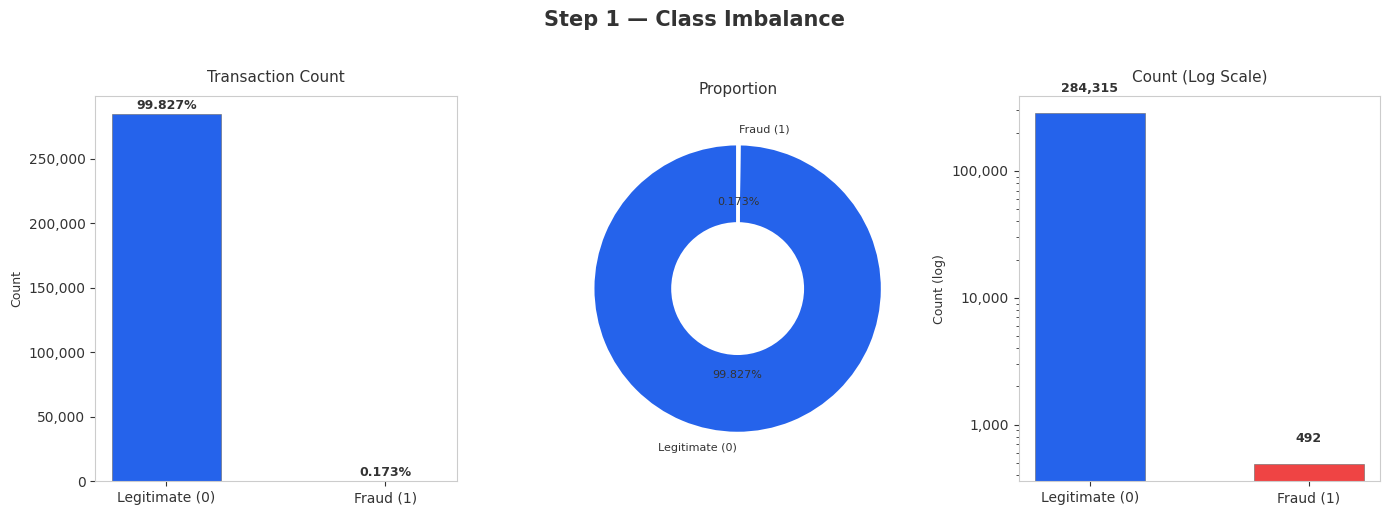

In [5]:
counts = df["Class"].value_counts().sort_index()
total  = counts.sum()
pcts   = counts / total * 100
labels = ["Legitimate (0)", "Fraud (1)"]
colors = ["#2563EB", "#EF4444"]

fig = plt.figure(figsize=(14, 5), facecolor="white")
fig.suptitle("Step 1 — Class Imbalance", fontsize=15, fontweight="bold",
             color="#333333", y=1.02)

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

# ── Bar chart ──
bars = ax1.bar(labels, counts.values, color=colors, width=0.5,
               edgecolor="#666666", linewidth=0.4)
for bar, pct in zip(bars, pcts):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + total * 0.005,
             f"{pct:.3f}%", ha="center", va="bottom",
             color="#333333", fontsize=9, fontweight="bold")
ax1.set_title("Transaction Count", color="#333333", fontsize=11, pad=10)
ax1.set_ylabel("Count", fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Donut ──
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=labels, colors=colors,
    autopct="%1.3f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    textprops=dict(color="#333333", fontsize=8)
)
for at in autotexts:
    at.set_color("#333333"); at.set_fontsize(8)
ax2.set_title("Proportion", color="#333333", fontsize=11, pad=10)

# ── Log-scale bar ──
ax3.bar(labels, counts.values, color=colors, width=0.5,
        edgecolor="#666666", linewidth=0.4)
ax3.set_yscale("log")
ax3.set_title("Count (Log Scale)", color="#333333", fontsize=11, pad=10)
ax3.set_ylabel("Count (log)", fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(ax3.patches, counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             cnt * 1.4, f"{cnt:,}",
             ha="center", va="bottom",
             color="#333333", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_step1_class_imbalance.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()


### Key Takeaways

| Insight | Implication |
|---|---|
| Severe class imbalance (~577:1) | **Accuracy is a misleading metric** — a model predicting all legitimate still gets >99% accuracy |
| Fraud is rare but costly | Prioritise **recall** for fraud class; missing a fraud is worse than a false alarm |
| Need resampling | Consider **SMOTE** (oversample minority) or **random undersampling** before modelling |
| Evaluation metric | Use **Precision-Recall AUC** and **F1-score**, not ROC-AUC alone |

---
**Next → Step 2:** Distribution of `Amount` and `Time` by class


---
## Step 2: Amount & Time Distributions by Class

`Amount` and `Time` are the only two features **not** PCA-transformed — so they carry real-world meaning.  
We compare their distributions across legitimate vs. fraud transactions to spot behavioural patterns.


### 2a — Transaction Amount by Class

In [6]:
legit = df[df["Class"] == 0]["Amount"]
fraud = df[df["Class"] == 1]["Amount"]

amount_summary = pd.DataFrame({
    "Legitimate": legit.describe(),
    "Fraud":      fraud.describe()
}).round(2)
amount_summary


,Legitimate,Fraud
count,284315.00,492.00
mean,88.29,122.21
std,250.11,256.68
min,0.00,0.00
25%,5.65,1.00
50%,22.00,9.25
75%,77.05,105.89
max,25691.16,2125.87


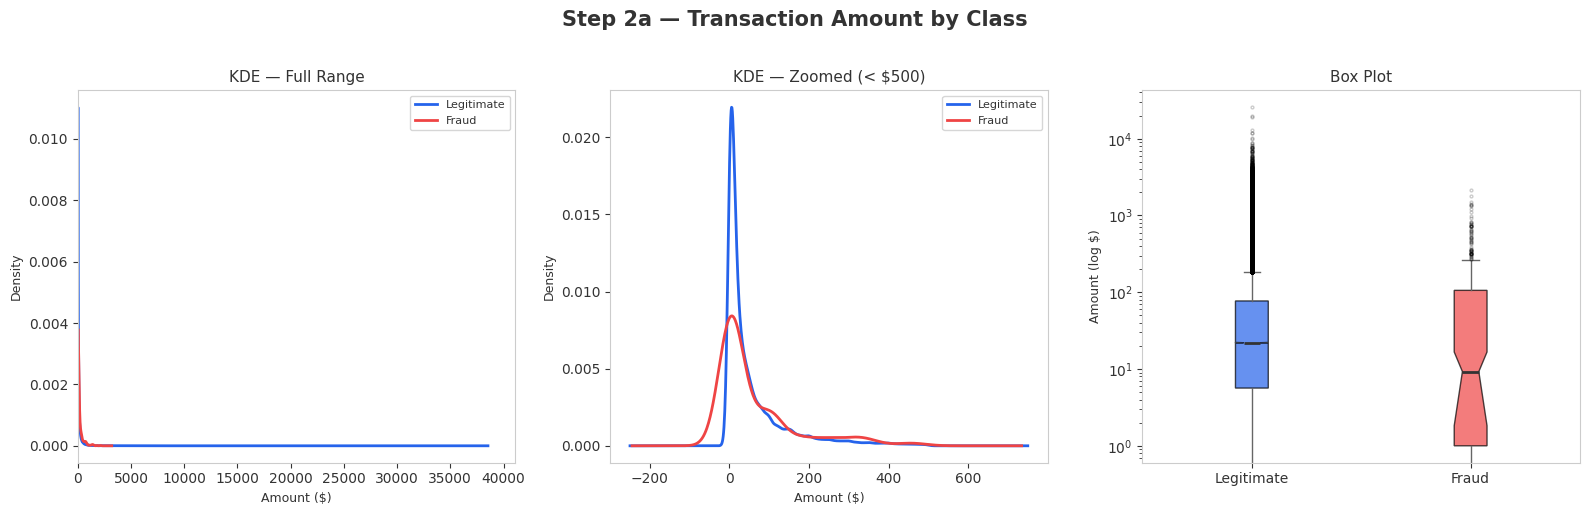

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="white")
fig.suptitle("Step 2a — Transaction Amount by Class", fontsize=15,
             fontweight="bold", color="#333333", y=1.02)

colors = {"legit": "#2563EB", "fraud": "#EF4444"}

# ── KDE overlay ──
ax = axes[0]
legit.plot.kde(ax=ax, color=colors["legit"], linewidth=2, label="Legitimate")
fraud.plot.kde(ax=ax, color=colors["fraud"],  linewidth=2, label="Fraud")
ax.set_xlim(left=0)
ax.set_title("KDE — Full Range", color="#333333", fontsize=11)
ax.set_xlabel("Amount ($)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=8)

# ── KDE zoomed ──
ax = axes[1]
legit[legit < 500].plot.kde(ax=ax, color=colors["legit"], linewidth=2, label="Legitimate")
fraud[fraud < 500].plot.kde(ax=ax,  color=colors["fraud"],  linewidth=2, label="Fraud")
ax.set_title("KDE — Zoomed (< $500)", color="#333333", fontsize=11)
ax.set_xlabel("Amount ($)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=8)

# ── Box plot ──
ax = axes[2]
bp = ax.boxplot(
    [legit, fraud], labels=["Legitimate", "Fraud"],
    patch_artist=True, notch=True, vert=True,
    medianprops=dict(color="#333333", linewidth=2),
    whiskerprops=dict(color="#666666"),
    capprops=dict(color="#666666"),
    flierprops=dict(marker="o", color="#999999", alpha=0.2, markersize=2)
)
for patch, color in zip(bp["boxes"], [colors["legit"], colors["fraud"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Box Plot", color="#333333", fontsize=11)
ax.set_ylabel("Amount ($)", fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("Amount (log $)", fontsize=9)

plt.tight_layout()
plt.savefig("eda_step2a_amount.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 2b — Transaction Time by Class

`Time` = seconds elapsed since the first transaction in the dataset (~48 hours of data).  
We convert to hours for readability.


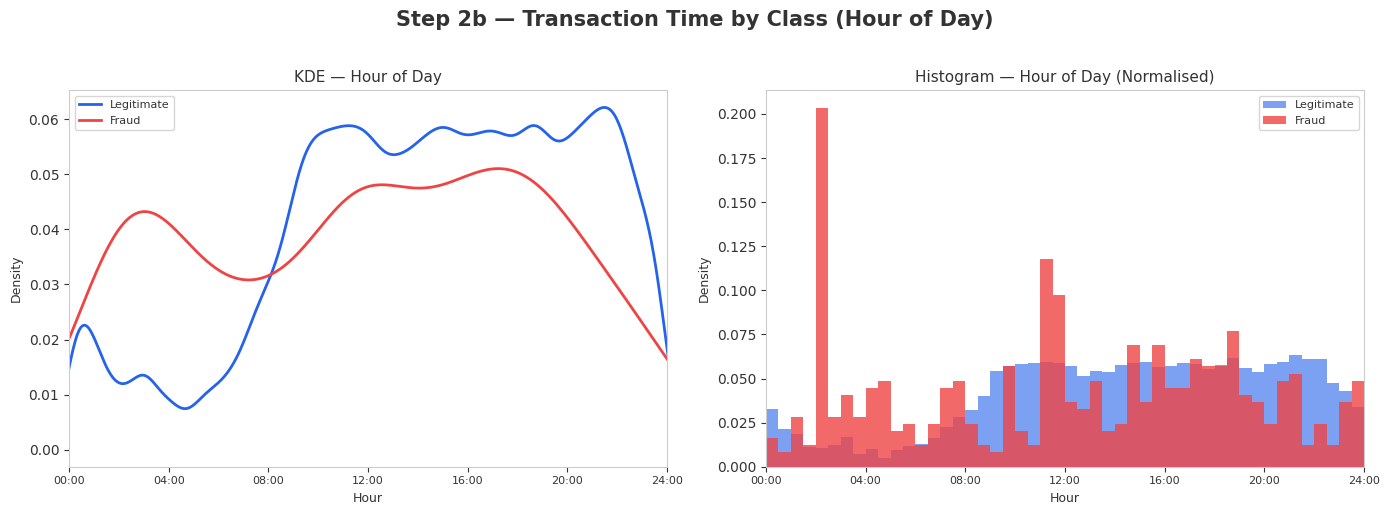

In [8]:
df["Hour"] = (df["Time"] / 3600) % 24   # wrap to 24-hour clock

legit_h = df[df["Class"] == 0]["Hour"]
fraud_h = df[df["Class"] == 1]["Hour"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")
fig.suptitle("Step 2b — Transaction Time by Class (Hour of Day)", fontsize=15,
             fontweight="bold", color="#333333", y=1.02)

# ── KDE by hour ──
ax = axes[0]
legit_h.plot.kde(ax=ax, color=colors["legit"], linewidth=2, label="Legitimate")
fraud_h.plot.kde(ax=ax,  color=colors["fraud"],  linewidth=2, label="Fraud")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 4)], fontsize=8)
ax.set_title("KDE — Hour of Day", color="#333333", fontsize=11)
ax.set_xlabel("Hour", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=8)

# ── Histogram by hour ──
ax = axes[1]
bins = np.linspace(0, 24, 49)
ax.hist(legit_h, bins=bins, color=colors["legit"], alpha=0.6,
        density=True, label="Legitimate")
ax.hist(fraud_h,  bins=bins, color=colors["fraud"],  alpha=0.8,
        density=True, label="Fraud")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 4)], fontsize=8)
ax.set_title("Histogram — Hour of Day (Normalised)", color="#333333", fontsize=11)
ax.set_xlabel("Hour", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_step2b_time.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 2c — Amount vs. Hour (Joint View)

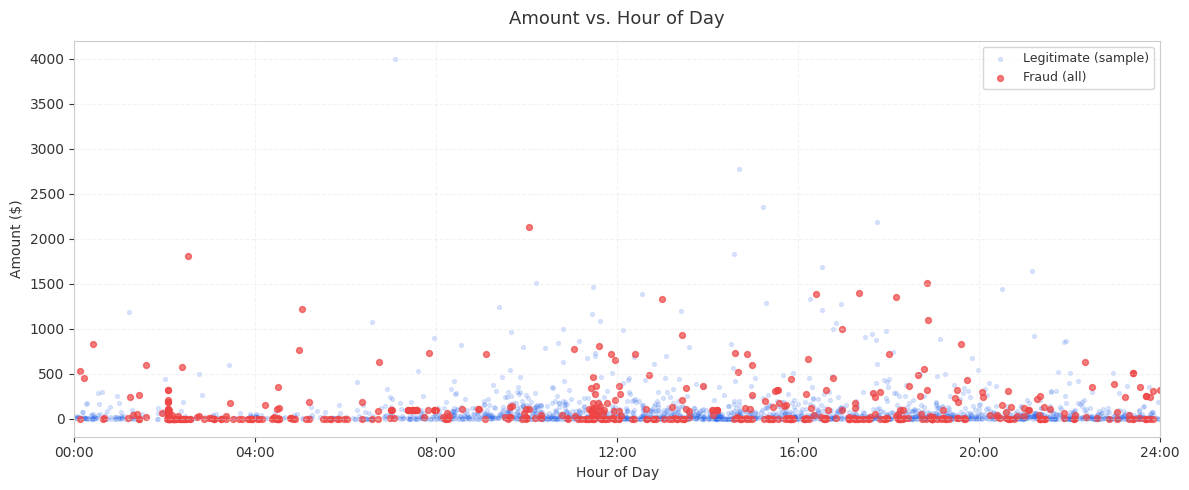

In [9]:
sample_legit = df[df["Class"] == 0].sample(2000, random_state=42)
sample_fraud = df[df["Class"] == 1]   # use all fraud rows

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(sample_legit["Hour"], sample_legit["Amount"],
           color=colors["legit"], alpha=0.15, s=8, label="Legitimate (sample)")
ax.scatter(sample_fraud["Hour"],  sample_fraud["Amount"],
           color=colors["fraud"],  alpha=0.7,  s=18, label="Fraud (all)")

ax.set_title("Amount vs. Hour of Day", color="#333333", fontsize=13, pad=12)
ax.set_xlabel("Hour of Day", fontsize=10)
ax.set_ylabel("Amount ($)", fontsize=10)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 4)])
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("eda_step2c_scatter.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Key Takeaways — Amount & Time

| Feature | Observation | Implication |
|---|---|---|
| **Amount** | Fraud transactions tend to be **smaller** on average | Fraudsters test cards with small charges |
| **Amount** | Legitimate transactions have a wider spread & higher max | Normal spending is more varied |
| **Time** | Fraud is more evenly spread across hours | Less drop-off during low-activity hours (2–6 AM) |
| **Time** | Legitimate transactions dip sharply at night | Fraudsters operate around the clock |
| **Both** | No single threshold separates classes cleanly | Features need to be combined — tree models handle this well |

---
**Next → Step 3:** PCA feature (V1–V28) distributions by class — finding the most discriminative components


---
## Step 3: PCA Feature Distributions by Class (V1–V28)

`V1–V28` are the result of PCA applied to the original (confidential) features.  
Even though they're transformed, their distributions **still differ** between fraud and legitimate transactions.  
This step identifies **which components are most discriminative** — i.e., best at separating the two classes.


### 3a — Rank Features by Discriminative Power (ANOVA F-score)

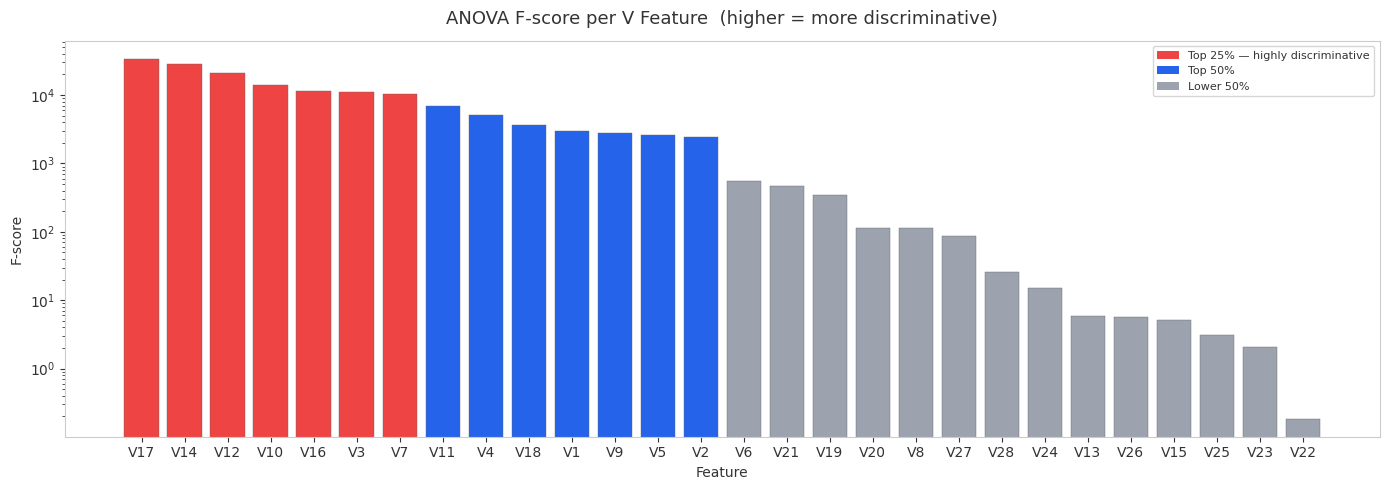

Top 8 most discriminative features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11']


In [10]:
from scipy import stats

v_cols = [f"V{i}" for i in range(1, 29)]

# Compute ANOVA F-statistic between classes for each V feature
f_scores = {}
for col in v_cols:
    g0 = df[df["Class"] == 0][col]
    g1 = df[df["Class"] == 1][col]
    f, p = stats.f_oneway(g0, g1)
    f_scores[col] = f

f_series = pd.Series(f_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5), facecolor="white")
ax.set_facecolor("white")

bar_colors = ["#EF4444" if f_series[c] >= f_series.quantile(0.75) else
              "#2563EB" if f_series[c] >= f_series.quantile(0.50) else
              "#9CA3AF" for c in f_series.index]

bars = ax.bar(f_series.index, f_series.values, color=bar_colors, edgecolor="#666666", linewidth=0.3)
ax.set_title("ANOVA F-score per V Feature  (higher = more discriminative)", 
             color="#333333", fontsize=13, pad=12)
ax.set_xlabel("Feature", fontsize=10)
ax.set_ylabel("F-score", fontsize=10)
ax.set_yscale("log")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#EF4444", label="Top 25% — highly discriminative"),
    Patch(facecolor="#2563EB", label="Top 50%"),
    Patch(facecolor="#9CA3AF", label="Lower 50%"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("eda_step3a_fscores.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

top_features = f_series.head(8).index.tolist()
print("Top 8 most discriminative features:", top_features)


### 3b — KDE Distributions: Top 8 Features

Overlaid KDE plots coloured by class — a clear separation means the feature is useful for detection.


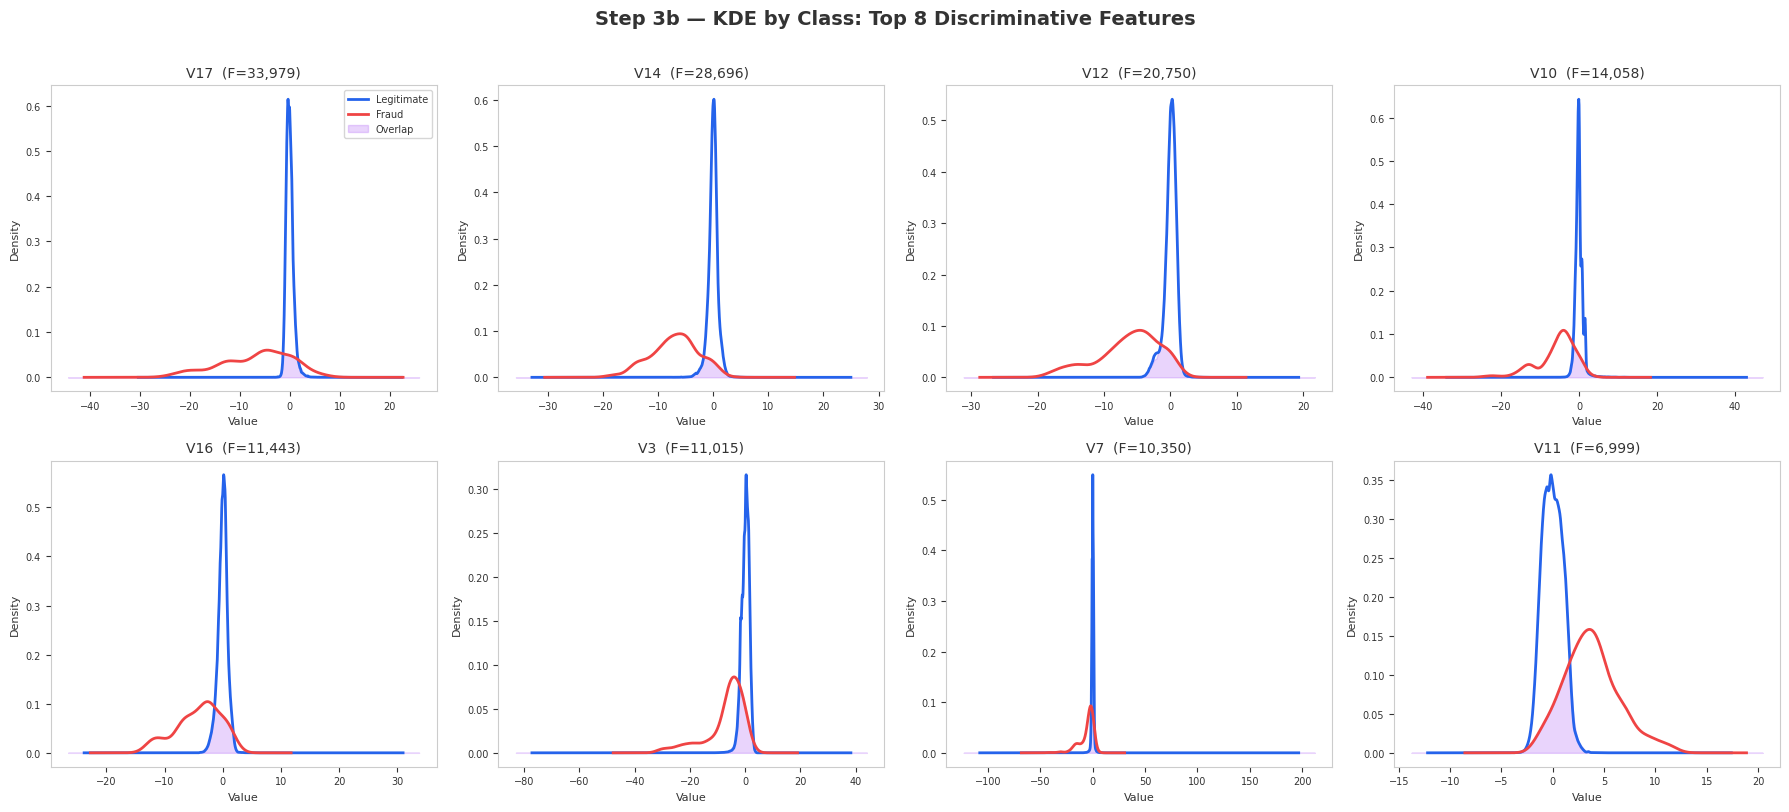

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor="white")
fig.suptitle("Step 3b — KDE by Class: Top 8 Discriminative Features",
             fontsize=14, fontweight="bold", color="#333333", y=1.01)

axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    g0 = df[df["Class"] == 0][col]
    g1 = df[df["Class"] == 1][col]

    g0.plot.kde(ax=ax, color="#2563EB", linewidth=2, label="Legitimate")
    g1.plot.kde(ax=ax, color="#EF4444", linewidth=2, label="Fraud")

    # Shade overlap area
    from scipy.stats import gaussian_kde
    xs = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 300)
    try:
        kde0 = gaussian_kde(g0.sample(min(5000, len(g0)), random_state=42))
        kde1 = gaussian_kde(g1)
        overlap = np.minimum(kde0(xs), kde1(xs))
        ax.fill_between(xs, overlap, alpha=0.25, color="#A855F7", label="Overlap")
    except Exception:
        pass

    ax.set_title(f"{col}  (F={f_series[col]:,.0f})", color="#333333", fontsize=10, pad=6)
    ax.set_xlabel("Value", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_step3b_kde_top8.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 3c — Mean Feature Values: Fraud vs. Legitimate

A heatmap comparing the **mean value** of each V feature per class.  
Large differences (bright cells) = strong signal for that feature.


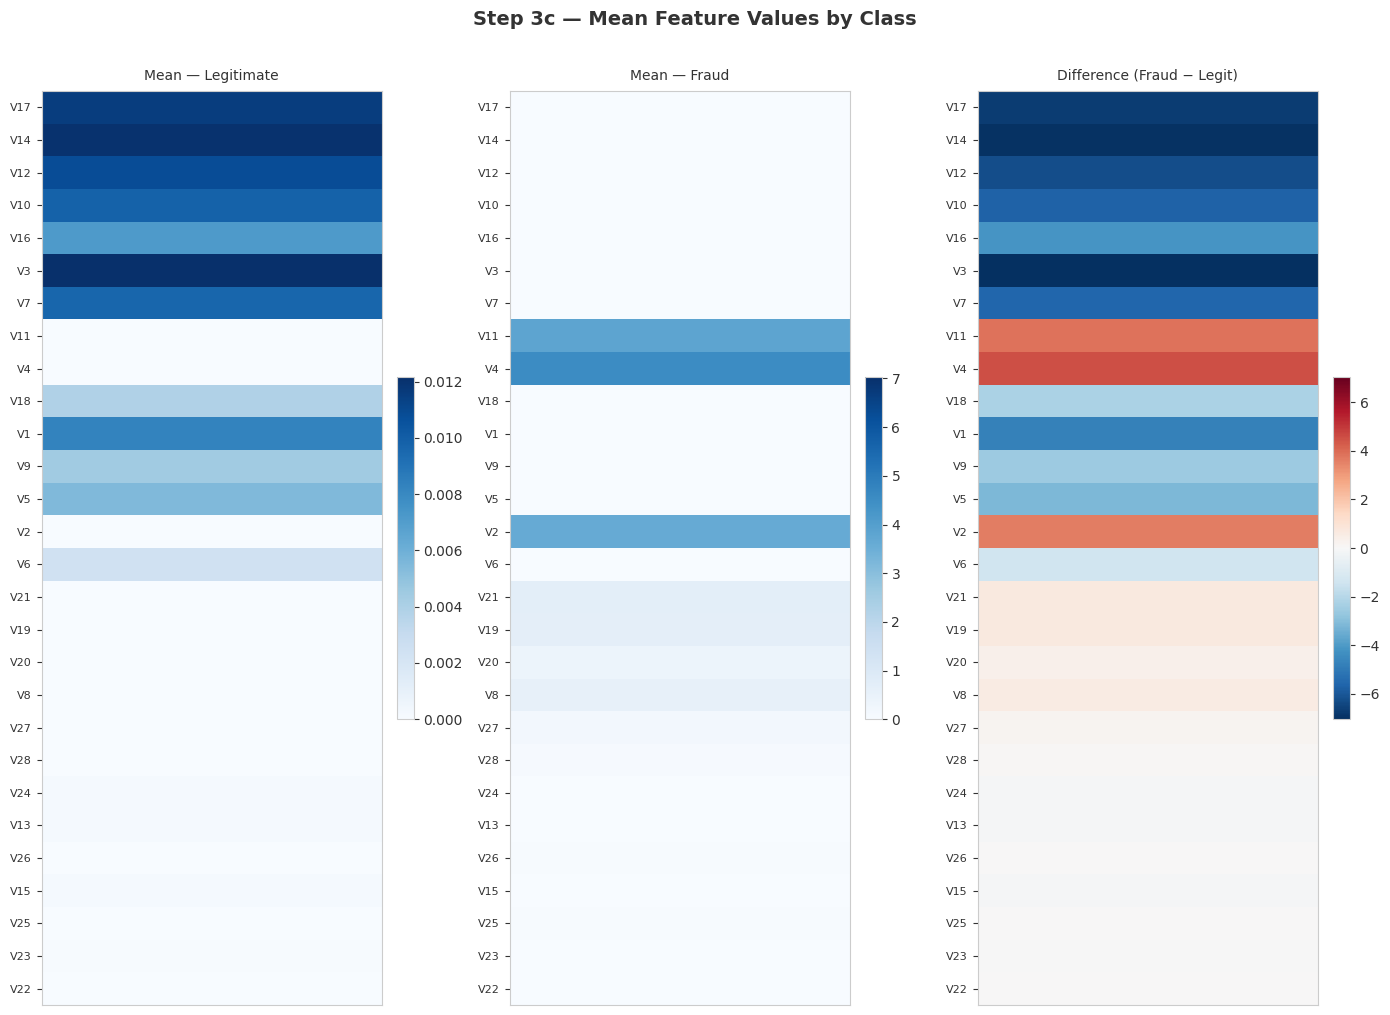

In [12]:
import matplotlib.colors as mcolors

means = df.groupby("Class")[v_cols].mean().T
means.columns = ["Legitimate (0)", "Fraud (1)"]
means["Difference"] = means["Fraud (1)"] - means["Legitimate (0)"]
means_sorted = means.reindex(f_series.index)  # sort by F-score

fig, axes = plt.subplots(1, 3, figsize=(14, 10), facecolor="white")
fig.suptitle("Step 3c — Mean Feature Values by Class", fontsize=14,
             fontweight="bold", color="#333333", y=1.01)

cmap_blue  = plt.cm.Blues
cmap_div   = plt.cm.RdBu_r

for ax, col, cmap, title in zip(
    axes,
    ["Legitimate (0)", "Fraud (1)", "Difference"],
    [cmap_blue, cmap_blue, cmap_div],
    ["Mean — Legitimate", "Mean — Fraud", "Difference (Fraud − Legit)"]
):
    ax.set_facecolor("white")
    vals = means_sorted[[col]].values
    vmax = np.abs(vals).max()
    vmin = -vmax if col == "Difference" else 0

    im = ax.imshow(vals, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(means_sorted)))
    ax.set_yticklabels(means_sorted.index, fontsize=8, color="#333333")
    ax.set_xticks([])
    ax.set_title(title, color="#333333", fontsize=10, pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("eda_step3c_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 3d — Violin Plots: Top 6 Features

Violin plots show the **full distribution shape** (not just mean/median) — useful to see if fraud 
clusters at specific value ranges.


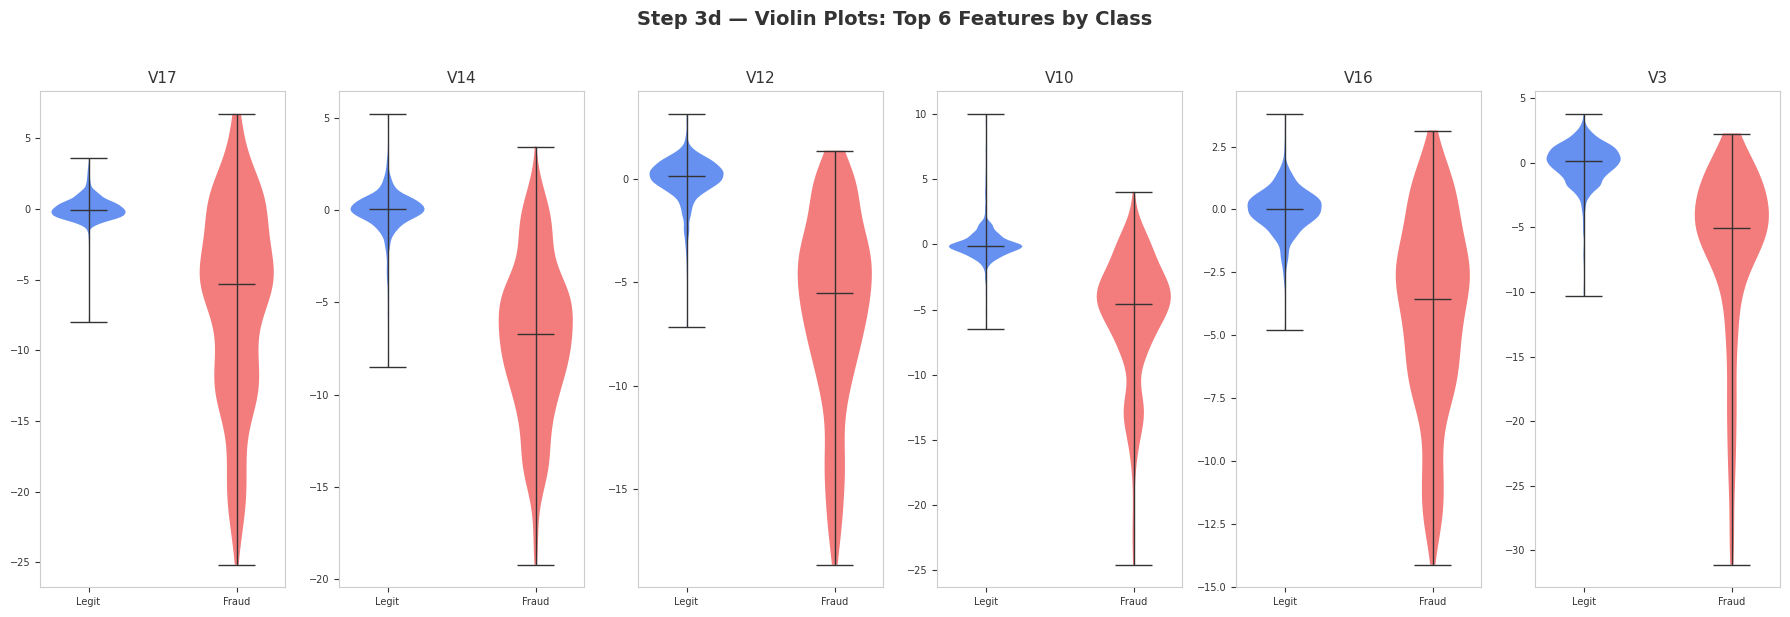

In [13]:
top6 = f_series.head(6).index.tolist()

fig, axes = plt.subplots(1, 6, figsize=(18, 6), facecolor="white")
fig.suptitle("Step 3d — Violin Plots: Top 6 Features by Class",
             fontsize=14, fontweight="bold", color="#333333", y=1.02)

for ax, col in zip(axes, top6):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    data_to_plot = [
        df[df["Class"] == 0][col].sample(2000, random_state=42).values,
        df[df["Class"] == 1][col].values
    ]

    parts = ax.violinplot(data_to_plot, positions=[0, 1],
                          showmedians=True, showextrema=True)

    for pc, color in zip(parts["bodies"], ["#2563EB", "#EF4444"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    for partname in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[partname].set_edgecolor("#333333")
        parts[partname].set_linewidth(1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legit", "Fraud"], fontsize=8, color="#333333")
    ax.set_title(col, color="#333333", fontsize=11, pad=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("eda_step3d_violin.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Key Takeaways — PCA Features

| Observation | Implication |
|---|---|
| Several V features (typically V4, V11, V12, V14, V17) show **strong separation** | These are the most useful features for a classifier |
| Fraud distributions are often **tighter / more concentrated** | Fraudulent transactions follow a narrower pattern |
| Some features show **near-zero separation** | Can potentially be dropped to reduce noise |
| No single feature perfectly separates classes | A combination of top features is needed |

> **Tip:** Use the F-score ranking to guide feature selection in your model. Features with F < 100 contribute little signal.

---
**Next → Step 4:** Correlation heatmap + t-SNE / UMAP dimensionality reduction


---
## Step 4: Correlation Heatmap & t-SNE / UMAP Dimensionality Reduction

Two complementary views:
- **Correlation heatmap** — linear relationships between all features and with `Class`
- **t-SNE / UMAP** — non-linear 2D projection to visually assess class separability


### 4a — Correlation Heatmap

Since V1–V28 are PCA components, they should be **uncorrelated with each other** by construction.  
The interesting signals are their correlations with `Amount`, `Time`, and `Class`.


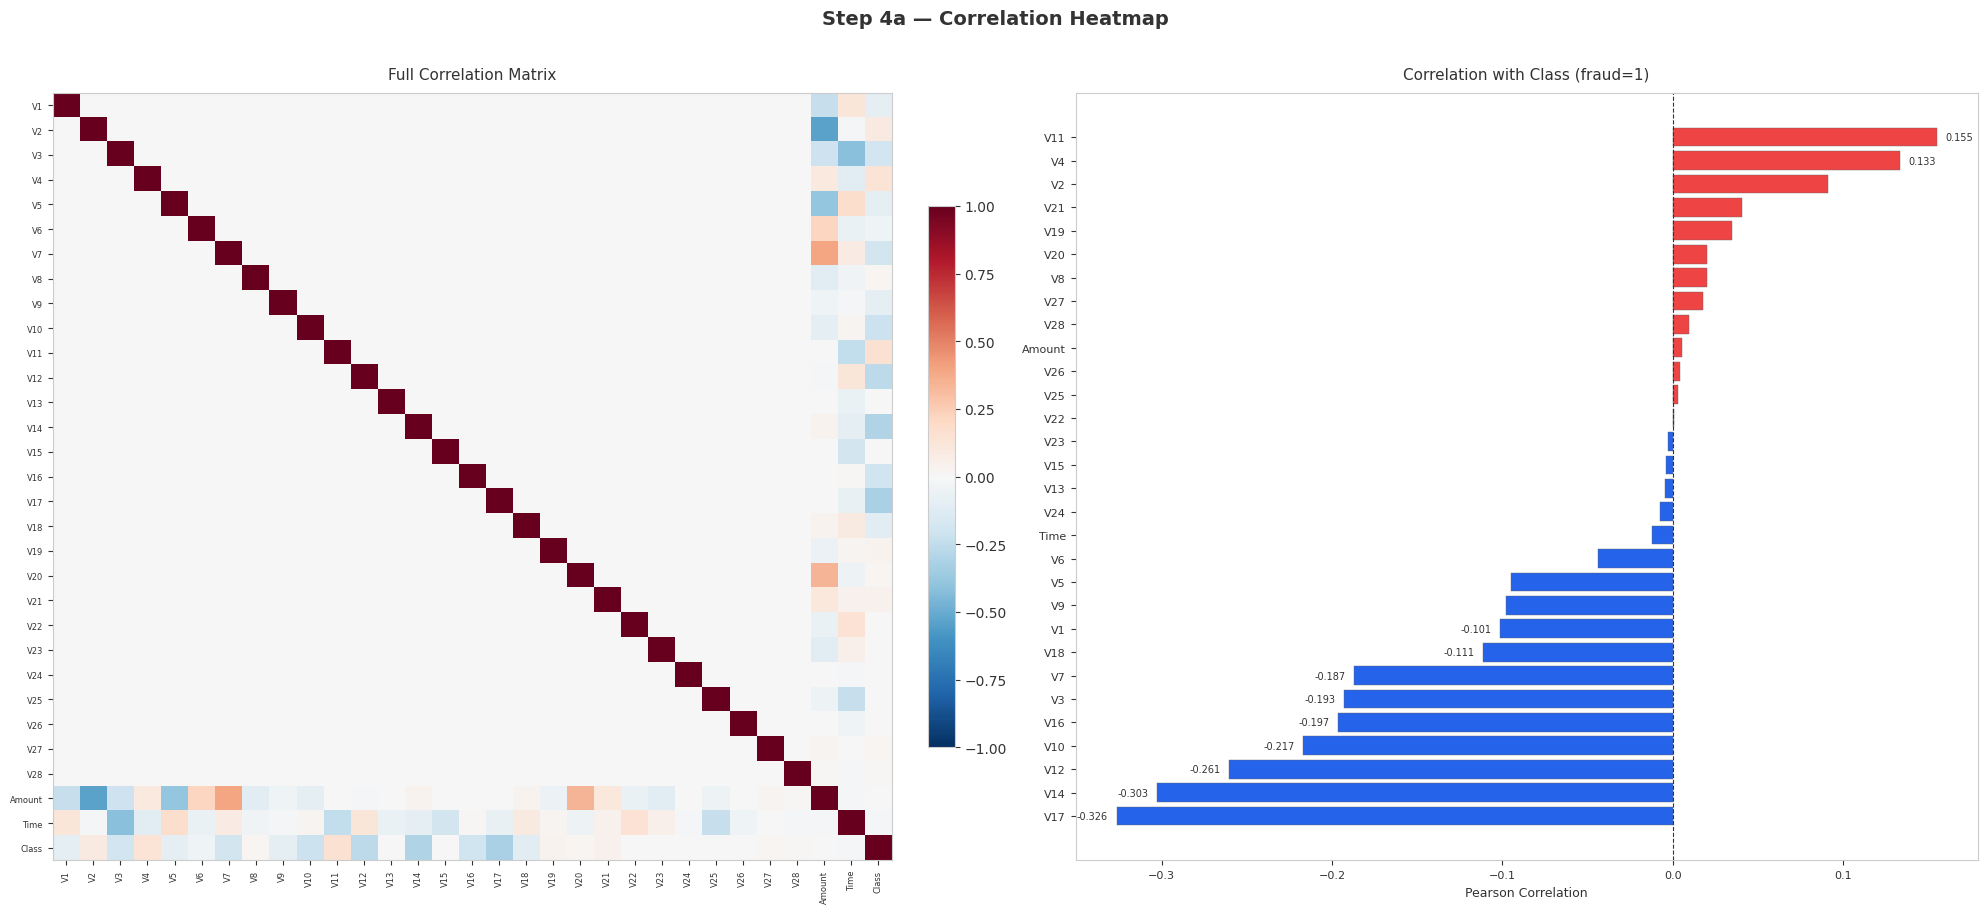

In [14]:
v_cols = [f"V{i}" for i in range(1, 29)]
feature_cols = v_cols + ["Amount", "Time", "Class"]

corr = df[feature_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor="white")
fig.suptitle("Step 4a — Correlation Heatmap", fontsize=14,
             fontweight="bold", color="#333333", y=1.01)

# ── Full heatmap ──
ax = axes[0]
ax.set_facecolor("white")
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6, color="#333333")
ax.set_yticklabels(feature_cols, fontsize=6, color="#333333")
ax.set_title("Full Correlation Matrix", color="#333333", fontsize=11, pad=10)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

# ── Correlation with Class only ──
ax = axes[1]
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")

corr_class = corr["Class"].drop("Class").sort_values()
bar_colors = ["#EF4444" if v > 0 else "#2563EB" for v in corr_class.values]
bars = ax.barh(corr_class.index, corr_class.values, color=bar_colors,
               edgecolor="#666666", linewidth=0.3)
ax.axvline(0, color="#333333", linewidth=0.8, linestyle="--")
ax.set_title("Correlation with Class (fraud=1)", color="#333333", fontsize=11, pad=10)
ax.set_xlabel("Pearson Correlation", fontsize=9)
ax.tick_params(labelsize=8)

# Annotate top correlators
for bar, val in zip(bars, corr_class.values):
    if abs(val) > 0.1:
        ax.text(val + (0.005 if val > 0 else -0.005),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center",
                ha="left" if val > 0 else "right",
                fontsize=7, color="#333333")

plt.tight_layout()
plt.savefig("eda_step4a_correlation.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 4b — t-SNE Projection

t-SNE reduces all 30 features to 2D while preserving **local neighbourhood structure**.  
If fraud points form distinct clusters → the model has a good chance of separating them.

> ⚠️ We use a **stratified sample** (all fraud + equal legitimate) to keep runtime manageable.  
> Full dataset t-SNE can take 10–20 minutes.


In [15]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Stratified sample: all fraud + same-size legitimate sample
fraud_df  = df[df["Class"] == 1]
legit_df  = df[df["Class"] == 0].sample(len(fraud_df) * 5, random_state=42)
sample_df = pd.concat([legit_df, fraud_df]).sample(frac=1, random_state=42)

features  = v_cols + ["Amount", "Time"]
X_sample  = StandardScaler().fit_transform(sample_df[features])
y_sample  = sample_df["Class"].values

print(f"Running t-SNE on {len(sample_df):,} samples ({len(fraud_df)} fraud + {len(legit_df)} legit)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            max_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_sample)
print("t-SNE done.")


Running t-SNE on 2,952 samples (492 fraud + 2460 legit)...
t-SNE done.


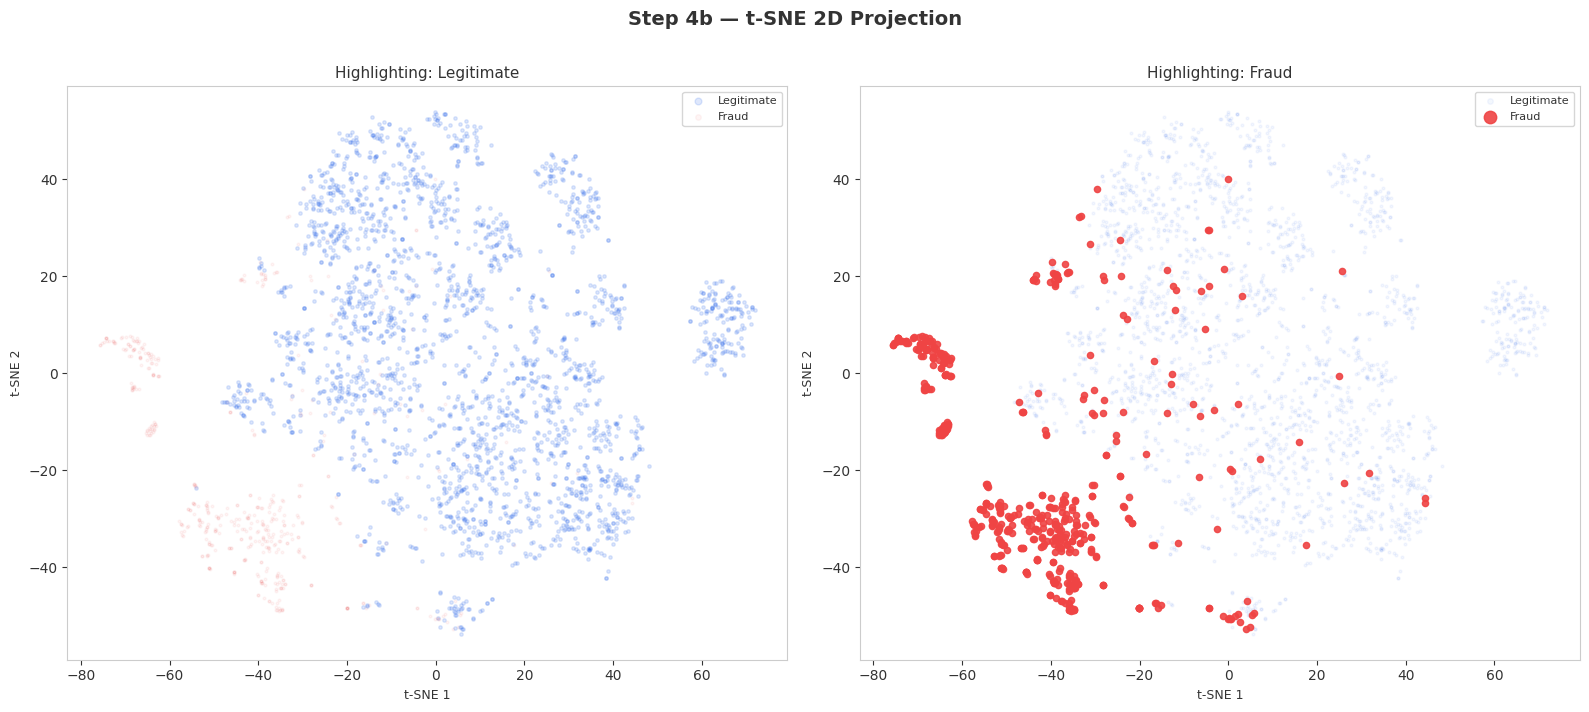

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")
fig.suptitle("Step 4b — t-SNE 2D Projection", fontsize=14,
             fontweight="bold", color="#333333", y=1.01)

colors_map = {0: "#2563EB", 1: "#EF4444"}
labels_map = {0: "Legitimate", 1: "Fraud"}

for ax, (class_val, alpha, size, zorder) in zip(
    axes,
    [(0, 0.15, 6, 1), (1, 0.9, 20, 2)]
):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    # Plot both classes, highlight one
    for cv in [0, 1]:
        mask = y_sample == cv
        a = alpha if cv == class_val else 0.05
        s = size  if cv == class_val else 4
        z = zorder if cv == class_val else 0
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_map[cv], alpha=a, s=s, zorder=z,
                   label=labels_map[cv])

    ax.set_title(f"Highlighting: {labels_map[class_val]}", color="#333333", fontsize=11)
    ax.set_xlabel("t-SNE 1", fontsize=9)
    ax.set_ylabel("t-SNE 2", fontsize=9)
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig("eda_step4b_tsne.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### 4c — UMAP Projection *(optional — requires `umap-learn`)*

UMAP is faster than t-SNE and better at preserving **global structure**.  
Run `pip install umap-learn` if not already installed.


Running UMAP on 2,952 samples...
UMAP done.


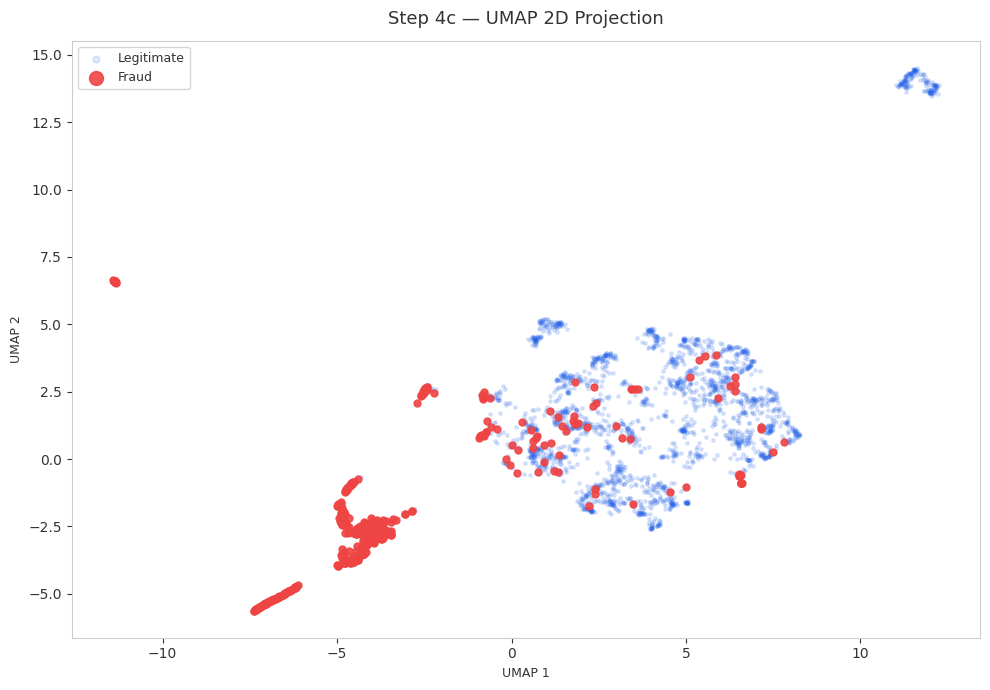

In [17]:
try:
    import umap

    print(f"Running UMAP on {len(sample_df):,} samples...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap  = reducer.fit_transform(X_sample)
    print("UMAP done.")

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    for cv, color, alpha, size, label in [
        (0, "#2563EB", 0.15, 6,  "Legitimate"),
        (1, "#EF4444", 0.90, 25, "Fraud"),
    ]:
        mask = y_sample == cv
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=color, alpha=alpha, s=size, label=label)

    ax.set_title("Step 4c — UMAP 2D Projection", color="#333333", fontsize=13, pad=12)
    ax.set_xlabel("UMAP 1", fontsize=9)
    ax.set_ylabel("UMAP 2", fontsize=9)
    ax.legend(fontsize=9, markerscale=2)

    plt.tight_layout()
    plt.savefig("eda_step4c_umap.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

except ImportError:
    print("umap-learn not installed. Run:  pip install umap-learn")
    print("Then re-run this cell.")
